In [1]:
!pip -q install ultralytics pandas==2.2.2 pillow==11.3.0 scikit-learn matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path

# ============================================================
# CHỌN YOLO MODEL Ở ĐÂY
# ============================================================
# Nếu chỉ muốn test YOLOv11m thì để như dưới.
# Nếu muốn test cả n/s/m thì sửa thành ["YOLOv11n", "YOLOv11s", "YOLOv11m"].

SELECTED_YOLO_ALIASES = ["YOLOv11m"]

# Các CNN baseline muốn test
SELECTED_CNN_ALIASES = ["DenseNet121", "ResNet50", "VGG16"]

# Test nhanh thì đặt số nhỏ, ví dụ 50.
# Test full thì để None.
MAX_TEST_IMAGES = None
# MAX_TEST_IMAGES = 50

# Lưu ảnh minh họa prediction
SAVE_ANNOTATED_IMAGES = True
SAVE_ANNOTATED_LIMIT = 80

# Kiểu vote cuối ảnh: "weighted" hoặc "majority"
AGG_METHOD = "weighted"

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_NAME = "Papaya_Leaf_Disease_Classification"

MANUAL_PROJECT_ROOT = None
# Nếu lỗi không tìm thấy project, dán path thật vào đây:
# MANUAL_PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")

def find_project_root():
    if MANUAL_PROJECT_ROOT is not None:
        manual = Path(MANUAL_PROJECT_ROOT)
        if manual.exists():
            return manual
        raise FileNotFoundError(f"MANUAL_PROJECT_ROOT không tồn tại: {manual}")

    candidates = [
        Path("/content/drive/MyDrive") / PROJECT_NAME,
    ]

    for c in candidates:
        if c.exists():
            return c

    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/.shortcut-targets-by-id"),
    ]

    for root in search_roots:
        if root.exists():
            found = list(root.rglob(PROJECT_NAME))
            for p in found:
                if p.is_dir() and (p / "prepared_data_v1").exists():
                    return p

    raise FileNotFoundError("Không tìm thấy project root.")

PROJECT_ROOT = find_project_root()

PREP_ROOT = PROJECT_ROOT / "prepared_data_v1"

YOLO_DATASET_ROOT = PREP_ROOT / "yolo_dataset"
YOLO_IMAGES_TEST = YOLO_DATASET_ROOT / "images" / "test"
YOLO_LABELS_TEST = YOLO_DATASET_ROOT / "labels" / "test"
DATA_YAML = YOLO_DATASET_ROOT / "dataset.yaml"

CNN_DATASET_ROOT = PREP_ROOT / "cnn_dataset"
CNN_HEALTHY_TEST = CNN_DATASET_ROOT / "test" / "Healthy"

MODEL_ROOT = PROJECT_ROOT / "Model"
YOLO_MODEL_ROOT = MODEL_ROOT / "YOLOv11"
CNN_BASELINE_ROOT = MODEL_ROOT / "CNN_Baselines"

PIPELINE_ROOT = MODEL_ROOT / "Pipeline_Evaluation_Baselines"
PIPELINE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT      :", PROJECT_ROOT)
print("YOLO_IMAGES_TEST  :", YOLO_IMAGES_TEST)
print("YOLO_LABELS_TEST  :", YOLO_LABELS_TEST)
print("CNN_HEALTHY_TEST  :", CNN_HEALTHY_TEST)
print("YOLO_MODEL_ROOT   :", YOLO_MODEL_ROOT)
print("CNN_BASELINE_ROOT :", CNN_BASELINE_ROOT)
print("PIPELINE_ROOT     :", PIPELINE_ROOT)

assert YOLO_IMAGES_TEST.exists(), f"Không thấy YOLO_IMAGES_TEST: {YOLO_IMAGES_TEST}"
assert YOLO_LABELS_TEST.exists(), f"Không thấy YOLO_LABELS_TEST: {YOLO_LABELS_TEST}"
assert CNN_HEALTHY_TEST.exists(), f"Không thấy CNN_HEALTHY_TEST: {CNN_HEALTHY_TEST}"
assert YOLO_MODEL_ROOT.exists(), f"Không thấy YOLO_MODEL_ROOT: {YOLO_MODEL_ROOT}"
assert CNN_BASELINE_ROOT.exists(), f"Không thấy CNN_BASELINE_ROOT: {CNN_BASELINE_ROOT}"

Mounted at /content/drive
PROJECT_ROOT      : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification
YOLO_IMAGES_TEST  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/images/test
YOLO_LABELS_TEST  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/labels/test
CNN_HEALTHY_TEST  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset/test/Healthy
YOLO_MODEL_ROOT   : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11
CNN_BASELINE_ROOT : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines
PIPELINE_ROOT     : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines


In [4]:
import os
import gc
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
import tensorflow as tf
from tensorflow import keras

from ultralytics import YOLO
from tqdm.auto import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ============================================================
# CLASS CONFIG
# ============================================================

YOLO_CLASS_NAMES = ["Anthracnose", "BacterialSpot", "Curl", "RingSpot"]
CNN_CLASS_NAMES  = ["Anthracnose", "BacterialSpot", "Curl", "Healthy", "RingSpot"]
ALL_CLASS_NAMES  = CNN_CLASS_NAMES

YOLO_ID_TO_CLASS = {i: name for i, name in enumerate(YOLO_CLASS_NAMES)}
YOLO_CLASS_TO_ID = {name: i for i, name in YOLO_ID_TO_CLASS.items()}

CNN_ID_TO_CLASS = {i: name for i, name in enumerate(CNN_CLASS_NAMES)}
CNN_CLASS_TO_ID = {name: i for i, name in CNN_ID_TO_CLASS.items()}

# ============================================================
# CNN BASELINE SPECS
# ============================================================
# Lưu ý:
# - VGG16/ResNet50/DenseNet121 cần preprocess_input tương ứng.
# - Không chia 1/255 thủ công.

CNN_SPECS = {
    "DenseNet121": {
        "img_size": 224,
        "preprocess_fn": tf.keras.applications.densenet.preprocess_input,
    },
    "ResNet50": {
        "img_size": 224,
        "preprocess_fn": tf.keras.applications.resnet50.preprocess_input,
    },
    "VGG16": {
        "img_size": 224,
        "preprocess_fn": tf.keras.applications.vgg16.preprocess_input,
    },
}

# ============================================================
# YOLO CONFIG
# ============================================================

YOLO_IMGSZ = 832
YOLO_IOU = 0.70

YOLO_CONF_START = 0.50
YOLO_CONF_MIN = 0.35
YOLO_CONF_STEP = 0.05

# Nếu YOLO không có bbox, CNN full-image dự đoán bệnh
# nhưng confidence thấp hơn ngưỡng này thì vẫn xem là Healthy.
FULL_CNN_DISEASE_MIN_PROB = 0.50

BBOX_EXPAND_RATIO = 0.10
MIN_CROP_SIZE = 8

TORCH_DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Torch CUDA available:", torch.cuda.is_available())
print("TORCH_DEVICE        :", TORCH_DEVICE)
print("TensorFlow version  :", tf.__version__)
print("Selected YOLO       :", SELECTED_YOLO_ALIASES)
print("Selected CNN        :", SELECTED_CNN_ALIASES)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch CUDA available: False
TORCH_DEVICE        : cpu
TensorFlow version  : 2.20.0
Selected YOLO       : ['YOLOv11m']
Selected CNN        : ['DenseNet121', 'ResNet50', 'VGG16']


In [5]:
def find_yolo_checkpoint(alias):
    candidates = [
        YOLO_MODEL_ROOT / alias / "weights" / "best.pt",
        YOLO_MODEL_ROOT / alias / "weights" / "last.pt",
    ]

    for p in candidates:
        if p.exists():
            return p

    # Fallback search nếu Drive shortcut làm lệch path
    found = list(PROJECT_ROOT.rglob("*.pt"))
    found = [p for p in found if alias in str(p) and "YOLOv11" in str(p)]

    priority_names = ["best.pt", "last.pt"]
    for name in priority_names:
        matches = [p for p in found if p.name == name]
        if matches:
            return matches[0]

    return None

def find_cnn_baseline_checkpoint(alias):
    run_dir = CNN_BASELINE_ROOT / alias

    candidates = [
        run_dir / "best_model.keras",
        run_dir / "best_stage2.keras",
        run_dir / "last_stage2.keras",
        run_dir / "best_stage1.keras",
        run_dir / "last_stage1.keras",
    ]

    for p in candidates:
        if p.exists():
            return p

    # Fallback search nếu path bị lệch
    found = list(PROJECT_ROOT.rglob("*.keras"))
    found = [p for p in found if alias in str(p) and "CNN_Baselines" in str(p)]

    priority_names = [
        "best_model.keras",
        "best_stage2.keras",
        "last_stage2.keras",
        "best_stage1.keras",
        "last_stage1.keras",
    ]

    for name in priority_names:
        matches = [p for p in found if p.name == name]
        if matches:
            return matches[0]

    return None

available_yolo = {}
for alias in SELECTED_YOLO_ALIASES:
    ckpt = find_yolo_checkpoint(alias)
    if ckpt is not None:
        available_yolo[alias] = ckpt

available_cnn = {}
for alias in SELECTED_CNN_ALIASES:
    ckpt = find_cnn_baseline_checkpoint(alias)
    if ckpt is not None:
        available_cnn[alias] = ckpt

print("===== AVAILABLE YOLO CHECKPOINTS =====")
for k, v in available_yolo.items():
    print(k, "=>", v)

print("\n===== AVAILABLE CNN BASELINE CHECKPOINTS =====")
for k, v in available_cnn.items():
    print(k, "=>", v)

missing_yolo = [a for a in SELECTED_YOLO_ALIASES if a not in available_yolo]
missing_cnn = [a for a in SELECTED_CNN_ALIASES if a not in available_cnn]

if missing_yolo:
    print("\n[WARNING] Không tìm thấy YOLO:", missing_yolo)

if missing_cnn:
    print("[WARNING] Không tìm thấy CNN:", missing_cnn)

assert len(available_yolo) > 0, "Không tìm thấy checkpoint YOLO nào."
assert len(available_cnn) > 0, "Không tìm thấy checkpoint CNN baseline nào."

===== AVAILABLE YOLO CHECKPOINTS =====
YOLOv11m => /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt

===== AVAILABLE CNN BASELINE CHECKPOINTS =====
DenseNet121 => /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/DenseNet121/best_model.keras
ResNet50 => /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage2.keras
VGG16 => /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/VGG16/best_model.keras


In [6]:
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(folder):
    folder = Path(folder)
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
    ])

def parse_yolo_label_file(label_path):
    label_path = Path(label_path)

    if not label_path.exists():
        return []

    cls_ids = []

    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            try:
                cls_id = int(float(parts[0]))
                if cls_id in YOLO_ID_TO_CLASS:
                    cls_ids.append(cls_id)
            except Exception:
                pass

    return cls_ids

def infer_true_class_from_yolo_label(label_path):
    cls_ids = parse_yolo_label_file(label_path)

    if len(cls_ids) == 0:
        return None

    most_common_id = Counter(cls_ids).most_common(1)[0][0]
    return YOLO_ID_TO_CLASS[most_common_id]

test_records = []

# 4 lớp bệnh từ YOLO test
for img_path in list_images(YOLO_IMAGES_TEST):
    lbl_path = YOLO_LABELS_TEST / f"{img_path.stem}.txt"
    true_class = infer_true_class_from_yolo_label(lbl_path)

    if true_class is None:
        continue

    test_records.append({
        "image_path": str(img_path),
        "true_class": true_class,
        "source": "yolo_test_disease",
        "label_path": str(lbl_path),
    })

# Healthy từ CNN test
for img_path in list_images(CNN_HEALTHY_TEST):
    test_records.append({
        "image_path": str(img_path),
        "true_class": "Healthy",
        "source": "cnn_test_healthy",
        "label_path": None,
    })

test_df = pd.DataFrame(test_records)

if MAX_TEST_IMAGES is not None:
    per_class = max(1, MAX_TEST_IMAGES // len(ALL_CLASS_NAMES))

    test_df = (
        test_df
        .groupby("true_class", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), per_class), random_state=SEED))
        .reset_index(drop=True)
    )

test_df = test_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_manifest_path = PIPELINE_ROOT / "pipeline_test_manifest_baselines.csv"
test_df.to_csv(test_manifest_path, index=False, encoding="utf-8-sig")

print("Total test images:", len(test_df))
display(test_df.groupby(["source", "true_class"]).size().reset_index(name="count"))
display(test_df.head())

print("Saved:", test_manifest_path)

Total test images: 291


,source,true_class,count
0,cnn_test_healthy,Healthy,34
1,yolo_test_disease,Anthracnose,54
2,yolo_test_disease,BacterialSpot,69
3,yolo_test_disease,Curl,54
4,yolo_test_disease,RingSpot,80


,image_path,true_class,source,label_path
0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Healthy,cnn_test_healthy,None
2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Anthracnose,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
3,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Curl,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
4,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Curl,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...


Saved: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/pipeline_test_manifest_baselines.csv


In [7]:
def safe_json_dumps(obj):
    try:
        return json.dumps(obj, ensure_ascii=False)
    except Exception:
        return str(obj)

def sanitize_filename(text):
    text = str(text)
    for ch in ["\\", "/", ":", "*", "?", '"', "<", ">", "|", " "]:
        text = text.replace(ch, "_")
    return text

def load_pil_rgb(image_path):
    return Image.open(image_path).convert("RGB")

def clamp_box(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(round(x1)), w - 1))
    y1 = max(0, min(int(round(y1)), h - 1))
    x2 = max(1, min(int(round(x2)), w))
    y2 = max(1, min(int(round(y2)), h))

    if x2 <= x1:
        x2 = min(w, x1 + 1)

    if y2 <= y1:
        y2 = min(h, y1 + 1)

    return x1, y1, x2, y2

def expand_xyxy(box, image_w, image_h, expand_ratio=0.10):
    x1, y1, x2, y2 = box

    bw = x2 - x1
    bh = y2 - y1

    ex = bw * expand_ratio
    ey = bh * expand_ratio

    return clamp_box(
        x1 - ex,
        y1 - ey,
        x2 + ex,
        y2 + ey,
        image_w,
        image_h,
    )

def crop_from_box(pil_img, box_xyxy, expand_ratio=0.10):
    w, h = pil_img.size

    x1, y1, x2, y2 = expand_xyxy(
        box_xyxy,
        image_w=w,
        image_h=h,
        expand_ratio=expand_ratio
    )

    if (x2 - x1) < MIN_CROP_SIZE or (y2 - y1) < MIN_CROP_SIZE:
        return None, (x1, y1, x2, y2)

    crop_img = pil_img.crop((x1, y1, x2, y2))
    return crop_img, (x1, y1, x2, y2)

def cnn_predict_pil(cnn_alias, cnn_model, pil_img):
    spec = CNN_SPECS[cnn_alias]
    img_size = spec["img_size"]
    preprocess_fn = spec["preprocess_fn"]

    img = pil_img.resize((img_size, img_size))
    arr = np.asarray(img).astype("float32")

    # Rất quan trọng:
    # VGG16/ResNet50/DenseNet121 cần preprocess_input riêng.
    arr = preprocess_fn(arr)

    arr = np.expand_dims(arr, axis=0)

    probs = cnn_model.predict(arr, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_class = CNN_ID_TO_CLASS[pred_id]
    pred_conf = float(probs[pred_id])

    return pred_class, pred_conf, probs.astype(float).tolist()

def yolo_detect_once(yolo_model, image_path, conf):
    results = yolo_model.predict(
        source=str(image_path),
        imgsz=YOLO_IMGSZ,
        conf=conf,
        iou=YOLO_IOU,
        device=TORCH_DEVICE,
        verbose=False,
    )

    r = results[0]
    boxes = []

    if r.boxes is None or len(r.boxes) == 0:
        return boxes

    for b in r.boxes:
        xyxy = b.xyxy.detach().cpu().numpy()[0].tolist()
        cls_id = int(b.cls.detach().cpu().numpy()[0])
        yolo_conf = float(b.conf.detach().cpu().numpy()[0])

        if cls_id not in YOLO_ID_TO_CLASS:
            continue

        boxes.append({
            "xyxy": [float(v) for v in xyxy],
            "yolo_class_id": cls_id,
            "yolo_class": YOLO_ID_TO_CLASS[cls_id],
            "yolo_conf": yolo_conf,
        })

    boxes = sorted(boxes, key=lambda x: x["yolo_conf"], reverse=True)
    return boxes

def conf_sequence(start=0.50, min_conf=0.35, step=0.05):
    vals = []
    c = start

    while c >= min_conf - 1e-9:
        vals.append(round(c, 3))
        c -= step

    return vals

In [8]:
def aggregate_crop_predictions(crop_preds, method="weighted"):
    if len(crop_preds) == 0:
        return "Healthy", {}, []

    scores = {cls: 0.0 for cls in ALL_CLASS_NAMES}

    if method == "majority":
        votes = Counter([p["cnn_class"] for p in crop_preds])
        max_vote = max(votes.values())
        candidates = [cls for cls, cnt in votes.items() if cnt == max_vote]

        weighted_scores = defaultdict(float)
        for p in crop_preds:
            weighted_scores[p["cnn_class"]] += p["cnn_conf"] * p["yolo_conf"]

        pred_class = sorted(
            candidates,
            key=lambda cls: weighted_scores.get(cls, 0.0),
            reverse=True
        )[0]

        for cls, cnt in votes.items():
            scores[cls] = float(cnt)

    else:
        for p in crop_preds:
            cls = p["cnn_class"]
            scores[cls] += float(p["cnn_conf"]) * float(p["yolo_conf"])

        pred_class = max(scores, key=scores.get)

    disease_list = []

    for p in crop_preds:
        if p["cnn_class"] != "Healthy":
            disease_list.append({
                "class": p["cnn_class"],
                "cnn_conf": p["cnn_conf"],
                "yolo_conf": p["yolo_conf"],
                "score": p["cnn_conf"] * p["yolo_conf"],
            })

    disease_list = sorted(disease_list, key=lambda x: x["score"], reverse=True)

    return pred_class, scores, disease_list

def run_hybrid_on_image(image_path, yolo_model, cnn_alias, cnn_model):
    image_path = Path(image_path)
    pil_img = load_pil_rgb(image_path)

    result = {
        "image_path": str(image_path),
        "pred_class": None,
        "reason": None,
        "num_boxes": 0,
        "conf_used": None,
        "full_cnn_class": None,
        "full_cnn_conf": None,
        "boxes": [],
        "crop_predictions": [],
        "final_scores": {},
        "disease_list": [],
        "error": None,
    }

    try:
        # 1. YOLO detect với conf ban đầu
        boxes = yolo_detect_once(
            yolo_model=yolo_model,
            image_path=image_path,
            conf=YOLO_CONF_START
        )

        conf_used = YOLO_CONF_START

        # 2. Nếu YOLO không có bbox, dùng CNN full image làm fallback
        if len(boxes) == 0:
            full_cls, full_conf, full_probs = cnn_predict_pil(
                cnn_alias=cnn_alias,
                cnn_model=cnn_model,
                pil_img=pil_img
            )

            result["full_cnn_class"] = full_cls
            result["full_cnn_conf"] = full_conf

            if full_cls == "Healthy" or full_conf < FULL_CNN_DISEASE_MIN_PROB:
                result["pred_class"] = "Healthy"
                result["reason"] = "no_yolo_box_full_cnn_healthy_or_low_conf"
                result["num_boxes"] = 0
                result["conf_used"] = YOLO_CONF_START
                return result

            # 3. Nếu CNN full image đoán bệnh, giảm conf YOLO để thử tìm bbox
            retry_confs = conf_sequence(
                start=YOLO_CONF_START - YOLO_CONF_STEP,
                min_conf=YOLO_CONF_MIN,
                step=YOLO_CONF_STEP
            )

            for c in retry_confs:
                boxes = yolo_detect_once(
                    yolo_model=yolo_model,
                    image_path=image_path,
                    conf=c
                )

                if len(boxes) > 0:
                    conf_used = c
                    break

            # 4. Nếu vẫn không tìm được bbox, kết luận Healthy theo logic của bạn
            if len(boxes) == 0:
                result["pred_class"] = "Healthy"
                result["reason"] = "no_yolo_box_after_conf_retry"
                result["num_boxes"] = 0
                result["conf_used"] = YOLO_CONF_MIN
                return result

        # 5. Có bbox thì crop từng bbox và đưa vào CNN baseline
        crop_preds = []

        for idx, box in enumerate(boxes):
            crop_img, expanded_box = crop_from_box(
                pil_img=pil_img,
                box_xyxy=box["xyxy"],
                expand_ratio=BBOX_EXPAND_RATIO
            )

            if crop_img is None:
                continue

            cnn_cls, cnn_conf, cnn_probs = cnn_predict_pil(
                cnn_alias=cnn_alias,
                cnn_model=cnn_model,
                pil_img=crop_img
            )

            crop_pred = {
                "box_index": idx,
                "xyxy": [float(v) for v in box["xyxy"]],
                "expanded_xyxy": [float(v) for v in expanded_box],
                "yolo_class": box["yolo_class"],
                "yolo_conf": float(box["yolo_conf"]),
                "cnn_class": cnn_cls,
                "cnn_conf": float(cnn_conf),
                "cnn_probs": cnn_probs,
            }

            crop_preds.append(crop_pred)

        if len(crop_preds) == 0:
            result["pred_class"] = "Healthy"
            result["reason"] = "boxes_exist_but_all_crops_invalid"
            result["num_boxes"] = len(boxes)
            result["conf_used"] = conf_used
            result["boxes"] = boxes
            return result

        final_cls, final_scores, disease_list = aggregate_crop_predictions(
            crop_preds=crop_preds,
            method=AGG_METHOD
        )

        result["pred_class"] = final_cls
        result["reason"] = f"yolo_boxes_cnn_{AGG_METHOD}_vote"
        result["num_boxes"] = len(boxes)
        result["conf_used"] = conf_used
        result["boxes"] = boxes
        result["crop_predictions"] = crop_preds
        result["final_scores"] = final_scores
        result["disease_list"] = disease_list

        return result

    except Exception as e:
        result["pred_class"] = "ERROR"
        result["reason"] = "exception"
        result["error"] = str(e)
        return result

In [9]:
def draw_prediction_image(image_path, pred_result, true_class, save_path):
    img = load_pil_rgb(image_path)
    draw = ImageDraw.Draw(img)

    pred_class = pred_result.get("pred_class", "NA")
    reason = pred_result.get("reason", "")

    title = f"GT: {true_class} | Pred: {pred_class} | {reason}"

    draw.rectangle([0, 0, img.size[0], 32], fill=(255, 255, 255))
    draw.text((5, 8), title, fill=(0, 0, 0))

    crop_preds = pred_result.get("crop_predictions", [])

    for p in crop_preds:
        x1, y1, x2, y2 = p["xyxy"]
        ex1, ey1, ex2, ey2 = p["expanded_xyxy"]

        # Red: YOLO bbox gốc
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=3)

        # Green: bbox sau khi expand
        draw.rectangle([ex1, ey1, ex2, ey2], outline=(0, 255, 0), width=2)

        label = (
            f"Y:{p['yolo_class']} {p['yolo_conf']:.2f} | "
            f"CNN:{p['cnn_class']} {p['cnn_conf']:.2f}"
        )

        ty = max(34, int(y1) - 20)

        draw.rectangle(
            [x1, ty, min(img.size[0], x1 + 440), ty + 20],
            fill=(255, 255, 255)
        )

        draw.text((x1 + 2, ty + 3), label, fill=(0, 0, 0))

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(save_path)


EVALUATING PAIR: YOLOv11m__DenseNet121
YOLO: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt
CNN : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/DenseNet121/best_model.keras


YOLOv11m__DenseNet121:   0%|          | 0/291 [00:00<?, ?it/s]

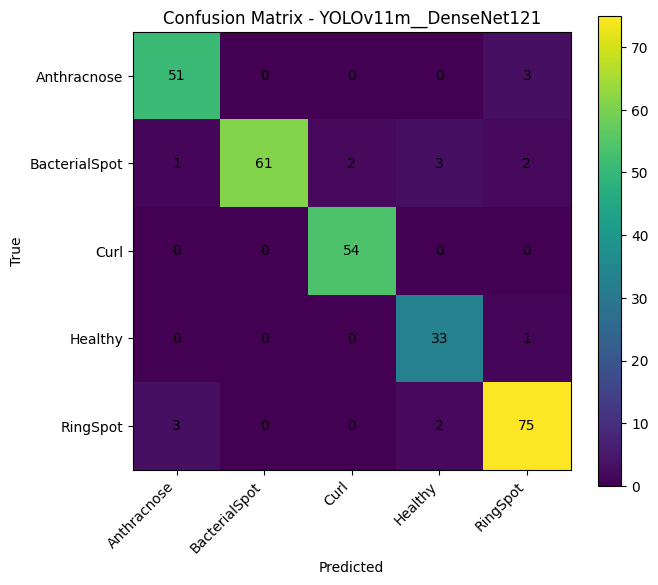


SUMMARY:
{
  "pair_name": "YOLOv11m__DenseNet121",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "DenseNet121",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/DenseNet121/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "num_error_predictions": 0,
  "accuracy": 0.9415807560137457,
  "macro_precision": 0.9371810840231893,
  "macro_recall": 0.947318130150611,
  "macro_f1": 0.9408806444187376,
  "weighted_precision": 0.9441393323288784,
  "weighted_recall": 0.9415807560137457,
  "weighted_f1": 0.9415978220657079,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/YOLOv11m__Dense

YOLOv11m__ResNet50:   0%|          | 0/291 [00:00<?, ?it/s]

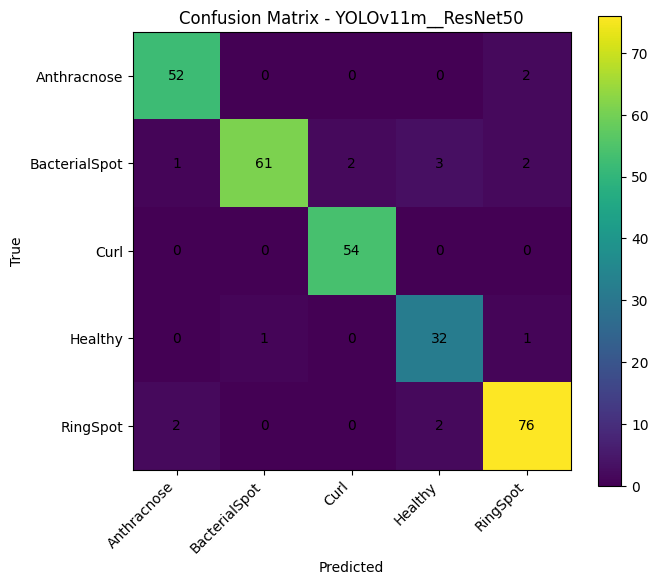


SUMMARY:
{
  "pair_name": "YOLOv11m__ResNet50",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "ResNet50",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage2.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "num_error_predictions": 0,
  "accuracy": 0.9450171821305842,
  "macro_precision": 0.9393495394570663,
  "macro_recall": 0.9476394809131383,
  "macro_f1": 0.9425504323390064,
  "weighted_precision": 0.9466673697616312,
  "weighted_recall": 0.9450171821305842,
  "weighted_f1": 0.9449364165540681,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/YOLOv11m__ResNet50/pip

YOLOv11m__VGG16:   0%|          | 0/291 [00:00<?, ?it/s]

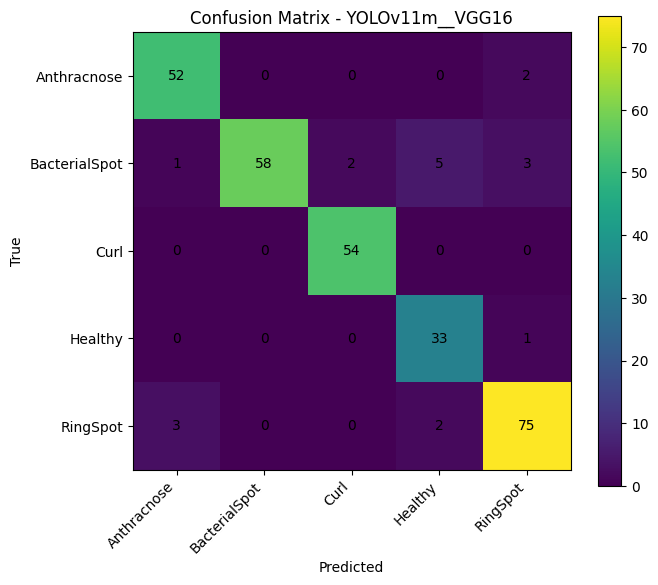


SUMMARY:
{
  "pair_name": "YOLOv11m__VGG16",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "VGG16",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/VGG16/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "num_error_predictions": 0,
  "accuracy": 0.9347079037800687,
  "macro_precision": 0.9287566137566137,
  "macro_recall": 0.9423261816804016,
  "macro_f1": 0.9328454929139627,
  "weighted_precision": 0.9393070783105149,
  "weighted_recall": 0.9347079037800687,
  "weighted_f1": 0.9345526980583467,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/YOLOv11m__VGG16/pipeline_predict

,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,num_error_predictions,accuracy,macro_precision,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11m__DenseNet121,YOLOv11m,DenseNet121,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.941581,0.937181,...,0.941598,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 19:23:49
1,YOLOv11m__ResNet50,YOLOv11m,ResNet50,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.945017,0.939350,...,0.944936,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 19:45:41
2,YOLOv11m__VGG16,YOLOv11m,VGG16,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.934708,0.928757,...,0.934553,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 20:23:59


Saved: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/all_pipeline_summary_baselines.csv


In [10]:
def evaluate_pair(yolo_alias, yolo_ckpt, cnn_alias, cnn_ckpt):
    pair_name = f"{yolo_alias}__{cnn_alias}"
    pair_dir = PIPELINE_ROOT / pair_name
    annotated_dir = pair_dir / "annotated_images"

    pair_dir.mkdir(parents=True, exist_ok=True)
    annotated_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print("EVALUATING PAIR:", pair_name)
    print("=" * 100)
    print("YOLO:", yolo_ckpt)
    print("CNN :", cnn_ckpt)

    yolo_model = YOLO(str(yolo_ckpt))
    cnn_model = keras.models.load_model(str(cnn_ckpt))

    rows = []
    annotated_count = 0

    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc=pair_name):
        image_path = row["image_path"]
        true_class = row["true_class"]

        pred_result = run_hybrid_on_image(
            image_path=image_path,
            yolo_model=yolo_model,
            cnn_alias=cnn_alias,
            cnn_model=cnn_model
        )

        pred_class = pred_result.get("pred_class", "ERROR")
        correct = int(pred_class == true_class)

        out_row = {
            "pair_name": pair_name,
            "yolo_alias": yolo_alias,
            "cnn_alias": cnn_alias,
            "image_path": image_path,
            "true_class": true_class,
            "pred_class": pred_class,
            "correct": correct,
            "source": row["source"],
            "reason": pred_result.get("reason"),
            "num_boxes": pred_result.get("num_boxes"),
            "conf_used": pred_result.get("conf_used"),
            "full_cnn_class": pred_result.get("full_cnn_class"),
            "full_cnn_conf": pred_result.get("full_cnn_conf"),
            "final_scores_json": safe_json_dumps(pred_result.get("final_scores", {})),
            "disease_list_json": safe_json_dumps(pred_result.get("disease_list", [])),
            "crop_predictions_json": safe_json_dumps(pred_result.get("crop_predictions", [])),
            "error": pred_result.get("error"),
        }

        rows.append(out_row)

        if SAVE_ANNOTATED_IMAGES and annotated_count < SAVE_ANNOTATED_LIMIT:
            should_save = (correct == 0) or (annotated_count < SAVE_ANNOTATED_LIMIT // 2)

            if should_save:
                status = "correct" if correct else "wrong"
                true_s = sanitize_filename(true_class)
                pred_s = sanitize_filename(pred_class)

                save_name = f"{idx:05d}_{status}_gt_{true_s}_pred_{pred_s}.jpg"

                draw_prediction_image(
                    image_path=image_path,
                    pred_result=pred_result,
                    true_class=true_class,
                    save_path=annotated_dir / save_name
                )

                annotated_count += 1

    result_df = pd.DataFrame(rows)
    result_csv = pair_dir / "pipeline_predictions.csv"
    result_df.to_csv(result_csv, index=False, encoding="utf-8-sig")

    # Chỉ tính metric trên prediction hợp lệ
    valid_df = result_df[result_df["pred_class"].isin(ALL_CLASS_NAMES)].copy()
    error_df = result_df[~result_df["pred_class"].isin(ALL_CLASS_NAMES)].copy()

    y_true = valid_df["true_class"].tolist()
    y_pred = valid_df["pred_class"].tolist()

    acc = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        average="weighted",
        zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        target_names=ALL_CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(pair_dir / "classification_report.csv", encoding="utf-8-sig")

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES
    )

    cm_df = pd.DataFrame(cm, index=ALL_CLASS_NAMES, columns=ALL_CLASS_NAMES)
    cm_df.to_csv(pair_dir / "confusion_matrix.csv", encoding="utf-8-sig")

    # Plot confusion matrix
    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {pair_name}")
    plt.colorbar()

    ticks = np.arange(len(ALL_CLASS_NAMES))
    plt.xticks(ticks, ALL_CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(ticks, ALL_CLASS_NAMES)

    for i in range(len(ALL_CLASS_NAMES)):
        for j in range(len(ALL_CLASS_NAMES)):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(pair_dir / "confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Accuracy theo từng lớp
    class_acc_df = (
        valid_df
        .groupby("true_class")["correct"]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            "count": "num_samples",
            "sum": "num_correct",
            "mean": "accuracy"
        })
    )

    class_acc_df.to_csv(pair_dir / "accuracy_by_class.csv", index=False, encoding="utf-8-sig")
    error_df.to_csv(pair_dir / "error_predictions.csv", index=False, encoding="utf-8-sig")

    summary = {
        "pair_name": pair_name,
        "yolo_alias": yolo_alias,
        "cnn_alias": cnn_alias,
        "yolo_ckpt": str(yolo_ckpt),
        "cnn_ckpt": str(cnn_ckpt),
        "num_test_images": int(len(result_df)),
        "num_valid_predictions": int(len(valid_df)),
        "num_error_predictions": int(len(error_df)),
        "accuracy": float(acc),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
        "agg_method": AGG_METHOD,
        "yolo_conf_start": YOLO_CONF_START,
        "yolo_conf_min": YOLO_CONF_MIN,
        "yolo_conf_step": YOLO_CONF_STEP,
        "full_cnn_disease_min_prob": FULL_CNN_DISEASE_MIN_PROB,
        "bbox_expand_ratio": BBOX_EXPAND_RATIO,
        "result_csv": str(result_csv),
        "pair_dir": str(pair_dir),
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    with open(pair_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)

    print("\nSUMMARY:")
    print(json.dumps(summary, indent=2, ensure_ascii=False))

    # Dọn RAM/GPU giữa các pair
    del yolo_model
    del cnn_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tf.keras.backend.clear_session()

    return summary

all_summaries = []

for yolo_alias, yolo_ckpt in available_yolo.items():
    for cnn_alias, cnn_ckpt in available_cnn.items():
        summary = evaluate_pair(
            yolo_alias=yolo_alias,
            yolo_ckpt=yolo_ckpt,
            cnn_alias=cnn_alias,
            cnn_ckpt=cnn_ckpt
        )

        all_summaries.append(summary)

summary_df = pd.DataFrame(all_summaries)

summary_csv = PIPELINE_ROOT / "all_pipeline_summary_baselines.csv"
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\n===== ALL PIPELINE SUMMARY =====")
display(summary_df)

print("Saved:", summary_csv)

,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,num_error_predictions,accuracy,macro_precision,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11m__ResNet50,YOLOv11m,ResNet50,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.945017,0.939350,...,0.944936,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 19:45:41
1,YOLOv11m__DenseNet121,YOLOv11m,DenseNet121,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.941581,0.937181,...,0.941598,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 19:23:49
2,YOLOv11m__VGG16,YOLOv11m,VGG16,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.934708,0.928757,...,0.934553,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 20:23:59


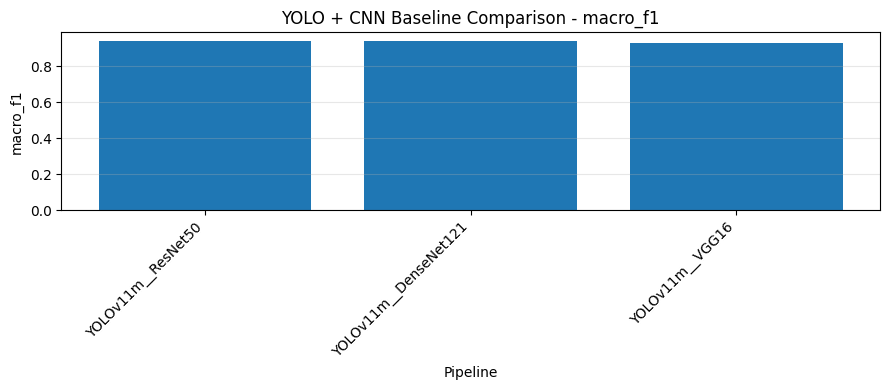

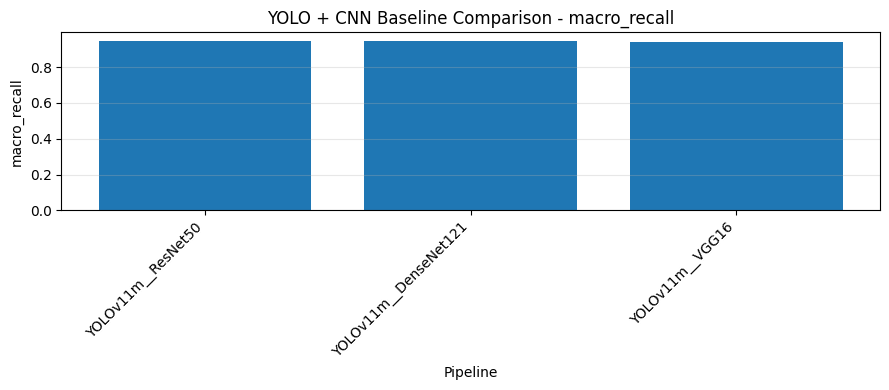

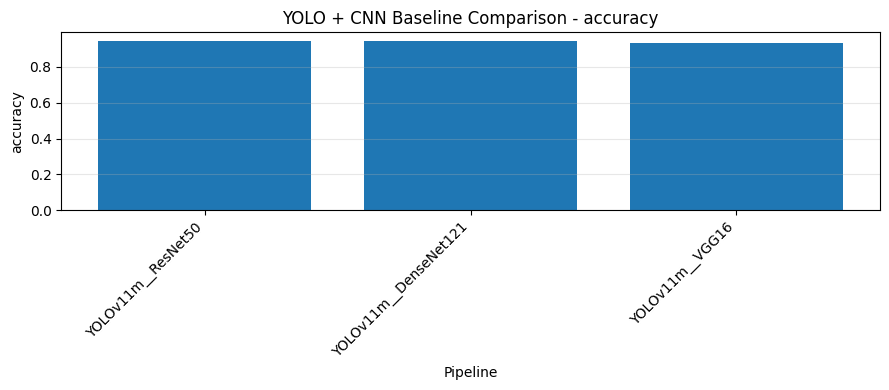

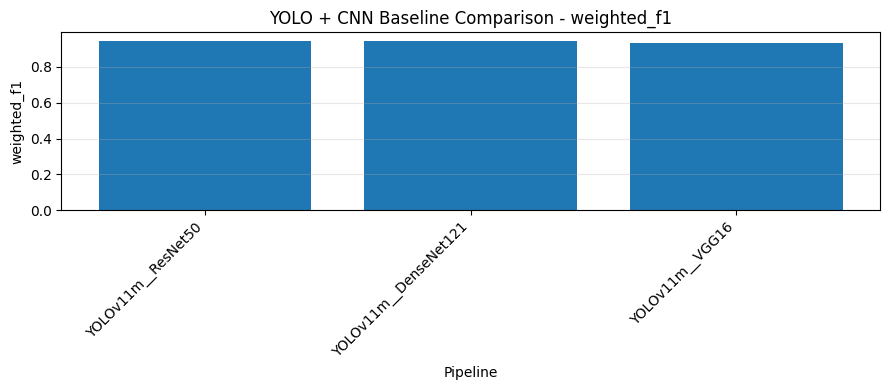

Best pipeline:


,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,num_error_predictions,accuracy,macro_precision,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11m__ResNet50,YOLOv11m,ResNet50,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0,0.945017,0.93935,...,0.944936,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-28 19:45:41


Saved: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/all_pipeline_summary_baselines_sorted.csv


In [11]:
summary_csv = PIPELINE_ROOT / "all_pipeline_summary_baselines.csv"
assert summary_csv.exists(), f"Không thấy summary CSV: {summary_csv}"

summary_df = pd.read_csv(summary_csv)

summary_df = summary_df.sort_values(
    by=["macro_f1", "macro_recall", "accuracy"],
    ascending=[False, False, False]
).reset_index(drop=True)

sorted_csv = PIPELINE_ROOT / "all_pipeline_summary_baselines_sorted.csv"
summary_df.to_csv(sorted_csv, index=False, encoding="utf-8-sig")

display(summary_df)

for metric in ["macro_f1", "macro_recall", "accuracy", "weighted_f1"]:
    if metric in summary_df.columns:
        plt.figure(figsize=(9, 4))
        plt.bar(summary_df["pair_name"], summary_df[metric])
        plt.title(f"YOLO + CNN Baseline Comparison - {metric}")
        plt.xlabel("Pipeline")
        plt.ylabel(metric)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(PIPELINE_ROOT / f"comparison_baselines_{metric}.png", dpi=200, bbox_inches="tight")
        plt.show()

print("Best pipeline:")
display(summary_df.head(1))

print("Saved:", sorted_csv)

In [12]:
best_pair = summary_df.iloc[0]["pair_name"]
best_pair_dir = PIPELINE_ROOT / best_pair
pred_csv = best_pair_dir / "pipeline_predictions.csv"

assert pred_csv.exists(), f"Không thấy prediction CSV: {pred_csv}"

pred_df = pd.read_csv(pred_csv)

print("Best pair:", best_pair)
print("Total predictions:", len(pred_df))
print("Correct:", int(pred_df["correct"].sum()))
print("Wrong:", int((pred_df["correct"] == 0).sum()))

print("\nAccuracy by true class:")
class_acc = (
    pred_df[pred_df["pred_class"].isin(ALL_CLASS_NAMES)]
    .groupby("true_class")["correct"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "num_samples",
        "sum": "num_correct",
        "mean": "accuracy"
    })
)

display(class_acc)

error_df = pred_df[pred_df["correct"] == 0].copy()

print("\nError cases:")
display(error_df[[
    "image_path",
    "true_class",
    "pred_class",
    "reason",
    "num_boxes",
    "conf_used",
    "full_cnn_class",
    "full_cnn_conf",
    "error"
]].head(50))

class_acc.to_csv(best_pair_dir / "accuracy_by_class.csv", index=False, encoding="utf-8-sig")
error_df.to_csv(best_pair_dir / "error_cases.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print(best_pair_dir / "accuracy_by_class.csv")
print(best_pair_dir / "error_cases.csv")

Best pair: YOLOv11m__ResNet50
Total predictions: 291
Correct: 275
Wrong: 16

Accuracy by true class:


,true_class,num_samples,num_correct,accuracy
0,Anthracnose,54,52,0.962963
1,BacterialSpot,69,61,0.884058
2,Curl,54,54,1.000000
3,Healthy,34,32,0.941176
4,RingSpot,80,76,0.950000



Error cases:


,image_path,true_class,pred_class,reason,num_boxes,conf_used,full_cnn_class,full_cnn_conf,error
11,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Healthy,BacterialSpot,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
23,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Curl,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
28,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,4,0.50,NaN,NaN,NaN
31,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Healthy,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
41,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,RingSpot,yolo_boxes_cnn_weighted_vote,4,0.50,NaN,NaN,NaN
54,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Healthy,no_yolo_box_after_conf_retry,0,0.35,BacterialSpot,0.945983,NaN
92,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Healthy,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
102,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Healthy,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
112,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Healthy,no_yolo_box_full_cnn_healthy_or_low_conf,0,0.50,Healthy,0.910686,NaN
140,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,3,0.50,NaN,NaN,NaN


Saved:
/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/YOLOv11m__ResNet50/accuracy_by_class.csv
/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation_Baselines/YOLOv11m__ResNet50/error_cases.csv
